In [4]:
import requests
from bs4 import BeautifulSoup
url = "https://books.toscrape.com/"
response = requests.get(url)
response = response.content
soup = BeautifulSoup(response, 'html.parser')
soup

<!DOCTYPE html>

<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js" lang="en-us"> <!--<![endif]-->
<head>
<title>
    All products | Books to Scrape - Sandbox
</title>
<meta content="text/html; charset=utf-8" http-equiv="content-type"/>
<meta content="24th Jun 2016 09:29" name="created"/>
<meta content="" name="description"/>
<meta content="width=device-width" name="viewport"/>
<meta content="NOARCHIVE,NOCACHE" name="robots"/>
<!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
<!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
<link href="static/oscar/favicon.ico" rel="shortcut icon"/>
<link href="static/oscar/css/styles.css" rel="stylesheet" type="text/css"/>
<link href="s

In [15]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

books = []

for i in range(1,51):
    url = f"https://books.toscrape.com/catalogue/page-{i}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.content, "html.parser")
    ol = soup.find("ol")
    articles = ol.find_all('article', class_='product_pod')

    for article in articles:
    
        # Title
        image = article.find("img")
        title = image["alt"]
    
        # Star rating
        star_tag = article.find("p", class_="star-rating")
        stars = star_tag["class"][1]  # e.g. "Three", "Five"
        star_text = star_tag["class"][1]
        star_map = {
        "One": 1,
        "Two": 2,
        "Three": 3,
        "Four": 4,
        "Five": 5
        }
        stars = star_map[star_text]
    
        # Price
        price = article.find("p", class_="price_color").text
        price = float(price.replace("£", ""))
    
        books.append([title, price, stars])


In [20]:
df = pd.DataFrame(books, columns=['Title', 'Price', 'Star Rating'])
df.to_csv('books.csv', index=False, encoding='utf-8')

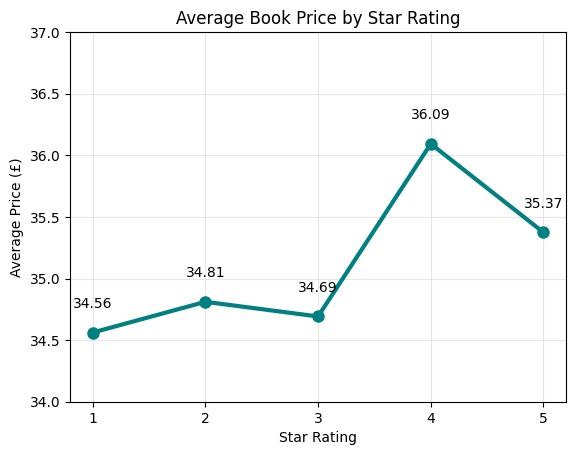

In [29]:
import matplotlib.pyplot as plt

# Ensure Stars column is numeric
df["Star Rating"] = df["Star Rating"].astype(int)

# Calculate average price
avg_price = df.groupby("Star Rating")["Price"].mean().reindex([1,2,3,4,5])

plt.figure()
plt.plot(
    avg_price.index, 
    avg_price.values, 
    marker='o',
    linewidth=3,
    markersize=8,
    color='teal'
    )

for x, y in zip(avg_price.index, avg_price.values):
    plt.text(x, y + 0.2, f"{y:,.2f}", ha='center')

plt.xlabel("Star Rating")
plt.ylabel("Average Price (£)")
plt.title("Average Book Price by Star Rating")
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(34, 37)
plt.grid(alpha=0.3)

plt.show()


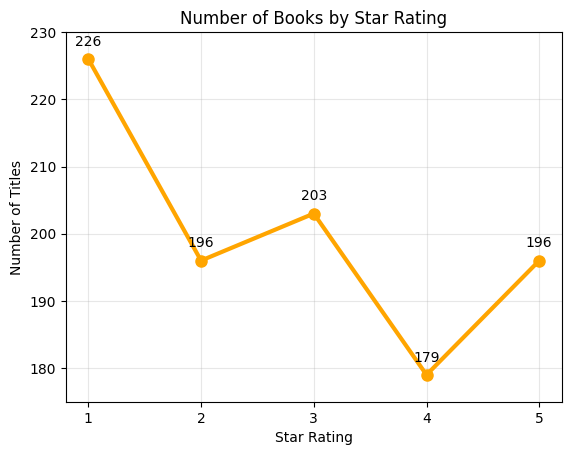

In [34]:
# Count number of books per rating
rating_counts = df["Star Rating"].value_counts().reindex([1,2,3,4,5])

plt.figure()
plt.plot(
    rating_counts.index, 
    rating_counts.values, 
    marker='o', 
    linewidth=3, 
    markersize=8,
    color='orange'
)

# Add labels
for x, y in zip(rating_counts.index, rating_counts.values):
    plt.text(x, y + 2, f"{y}", ha='center')

plt.xlabel("Star Rating")
plt.ylabel("Number of Titles")
plt.title("Number of Books by Star Rating")
plt.xticks([1,2,3,4,5])
plt.ylim(175, 230)
plt.grid(alpha=0.3)

plt.show()

